# Non-Autonomous Terms and VF-b Test
This notebook uses the best candidates from SINDy_FHN.ipynb for fitting data.  These include the following options:
* Model - VF-b (most realistic FHN model)
* Optimizer - SSR
* feature_library - degree 3 polynomials

In [1]:
import math
import numpy as np
from scipy.integrate import odeint
from scipy import fft
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps

In [2]:
# The old, non-truncated autonomous term (can be a problem for large exponents).
# Params:
#   t (1d array): Time input vector
def smooth_non_aut_old(t):
    return 1. / (1. + np.exp((25*np.sin(0.02*t))**2))

# A differentiable non-autonomous term truncated from the Taylor series of the above term.
# Params:
#   t (1d array): Time input vector
def smooth_non_aut(t):
    return 1. / (2. + (200.*np.sin(0.02*t))**4)

# Logical step function non-autonomous term.
# Params:
#   t (1d array): Time input vector
#   period (float): The period of the stimulus
#   dur (float): The time duration of the stimulus
#   mag (float): The magnitude of the stimulus
def logical_non_aut(t, period=155.0, dur=5.0, mag=0.5):
    stimulus = mag * (np.mod(t, period) <= dur)
    
    return stimulus

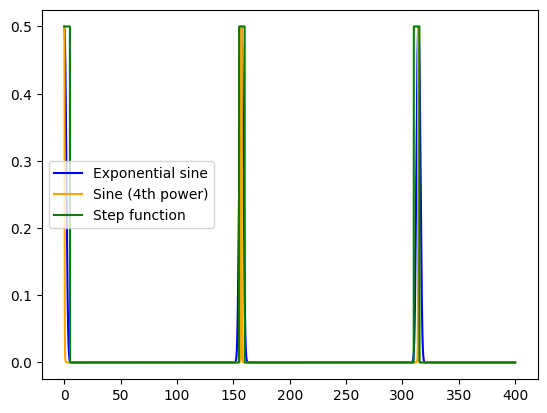

In [3]:
# Compare the forcing functions. Note that we can't actually use the exponential since it will encounter overflow for the peak tightness
# that we need; instead, take part of the Taylor series, then throw out the terms we don't need while still maintaing a representative shape.
t = np.arange(0,400,0.01)
plt.plot(t, smooth_non_aut_old(t), color = 'blue', label='Exponential sine')
plt.plot(t, smooth_non_aut(t), color='orange', label='Sine (4th power)')
plt.plot(t, logical_non_aut(t), color='green', label='Step function')
plt.legend()

# 1.) VF-FHN
Now, let's try fitting the above with some non-autonomous terms included.

In [4]:
'''
Generate the data using the VF-b modified FHN equations:
Params:
    state (2d array):        Contains the state variables u and v
    t (1d array):            Time input
    non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
    alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 1.0, eps = 0.005, theta = -0.05, mu = 1.0 (Old auto-oscillatory parameters used to get these equations)
'''
def fhn_vf_b(state, t, non_aut_term, alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0):
    u, v = state
    u_dot = mu*u*(1 - u)*(u - alpha) - u*v  # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*((beta - u)*(u - gamma) - delta*v - theta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# Time step and initial values; seems like 0-600 is minimum timeframe needed to identify dynamics
dt = 0.01
t_vf_b = np.arange(0,2000,dt)
x_0_vf_b = np.array([0,0])
states_vf_b = odeint(fhn_vf_b, x_0_vf_b, t_vf_b, args=(logical_non_aut,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> logical_non_aut

In [5]:
# Run SINDy on VF-FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_vf_b = ps.SSR(alpha=0.00001)
model_vf_b = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_b)
model_vf_b.fit(states_vf_b, t=t_vf_b)
model_vf_b.print(precision=5)

(u)' = 0.08034 1 + 2.03710 u + -2.76611 v + -3.36638 u^2 + -6.73926 u v + 30.87274 v^2 + 1.31222 u^3 + 6.21198 u^2 v + 1.95761 u v^2 + -106.66981 v^3
(v)' = -0.00145 1 + 0.00705 u + -0.00500 u^2


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

Text(0.5, 1.0, 'Values of u vs. v')

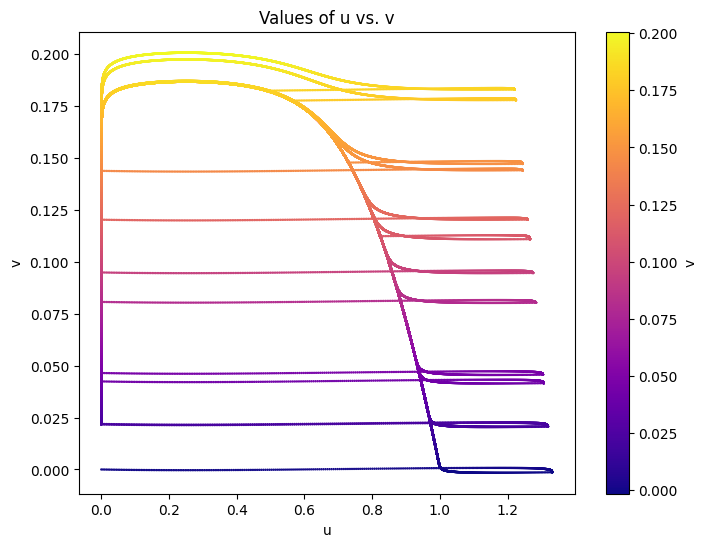

In [6]:
# Plot results - u vs. v
df_states_vf_b = pd.DataFrame(states_vf_b, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf_b['u'], 
    df_states_vf_b['v'], 
    c=df_states_vf_b['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.004995107016479037, 0.009980826703339636, 0.014957746783822216, 0.019926489807614044, 0.024887623317393276, 0.029841716253699257, 0.03478932843753817, 0.039731009161689146, 0.04466729777099303]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


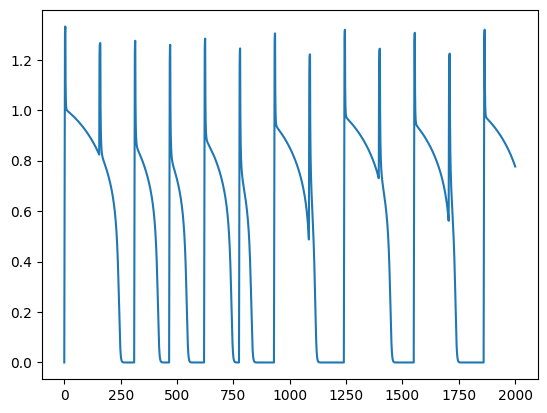

In [7]:
# Plot result - time domain - u vs. t
u_vf_b = df_states_vf_b['u'].tolist()
print(u_vf_b[0:10])
print(t_vf_b[0:10])

plt.plot(t_vf_b,u_vf_b)

# 2.) FHN
Now, fit standard FHN model with non-autonomous terms.

In [8]:
'''
Standard FitzHugh-Nagumo equations for comparison w/ the above method.
Params:
    state (2d array):        Contains the state variables u and v
    t (1d array):            Time input
    non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
    alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005 (delta = 1.0 for auto-oscillatory state)
'''
def fhn(state, t, non_aut_term, alpha = 0.1, beta = 0.5, gamma = 1, delta = 0.0, eps = 0.01):
    u, v = state
    u_dot = u*(1-u)*(u-alpha) - v   # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*(beta*u - gamma*v - delta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# Standard FHN parameters
t_fhn = np.arange(0,2000,dt)
x_0_fhn = np.array([0,0])
states_fhn = odeint(fhn, x_0_fhn, t_fhn, args=(logical_non_aut,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> logical_non_aut

In [9]:
# Run SINDy on FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_fhn = ps.SSR(alpha=0.00001)
model_fhn = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn)
model_fhn.print(precision=5)

(u)' = 0.14197 1 + 2.27544 u + 2.87700 v + -2.72306 u^2 + -33.54242 u v + -38.74048 v^2 + 0.74404 u^3 + 18.01575 u^2 v + 115.52271 u v^2 + 61.50945 v^3
(v)' = 0.00500 u + -0.01000 v


In [10]:
# Run SINDy on FHN w/ test implementation to directly ID non-autonomous terms
# TODO This is currently in terms of u and v instead of t; figure out if possible to implement a function in terms of time
# stimulation_functions = [lambda t : 1. / (2. + (200.*np.sin(0.02*t))**4)]
# lib_custom = ps.CustomLibrary(library_functions=stimulation_functions)  # Also FourierLibrary() as a possibility
# lib_combined = ps.GeneralizedLibrary([ps.PolynomialLibrary(degree=3), lib_custom])

# TODO Why does using standard function library (e.g., removing feature_library argument) result in fewer extraneous terms?
model_fhn = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn)
model_fhn.print(precision=5)

(u)' = 0.14197 1 + 2.27544 u + 2.87700 v + -2.72306 u^2 + -33.54242 u v + -38.74048 v^2 + 0.74404 u^3 + 18.01575 u^2 v + 115.52271 u v^2 + 61.50945 v^3
(v)' = 0.00500 u + -0.01000 v


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 uv - 1 u^3 \\
    \dot{v} &= 0.005 - 0.01v \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1uv - 1 u^3 \\
    \dot{v} &= - 0.01 + 0.005 - 0.01v \\
\end{align}

Text(0.5, 1.0, 'Values of u vs. v')

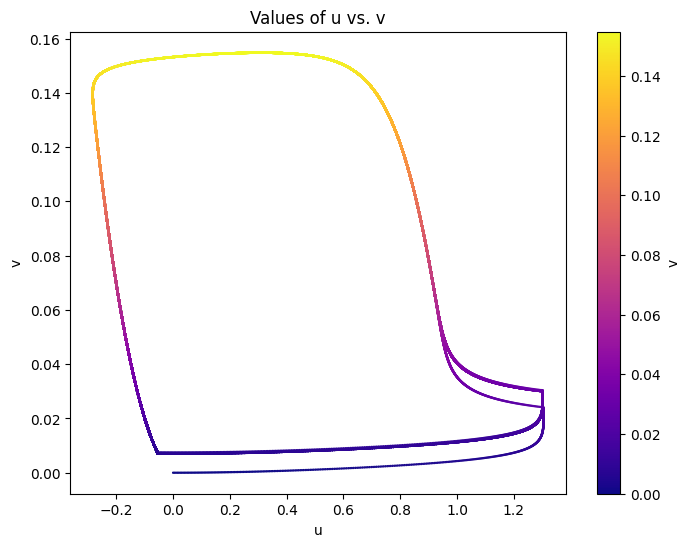

In [11]:
# Plot results - u vs. v
df_states_fhn = pd.DataFrame(states_fhn, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_fhn['u'], 
    df_states_fhn['v'], 
    c=df_states_fhn['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

# Experimental Section
Includes subtraction of logical_non_aut before passing to SINDy, FFT of voltage response, etc.

[0.0, 0.0049975933023779, 0.009990738495646585, 0.014979945056774685, 0.019965781994200738, 0.024948754100629432, 0.029929371507689605, 0.03490814024490694, 0.03988555392252668, 0.04486210036632816]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


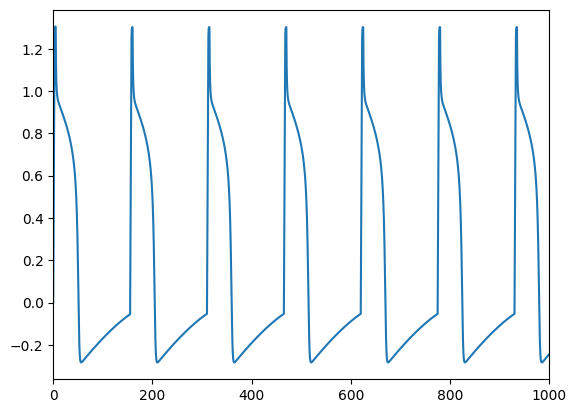

(0.0, 1000.0)

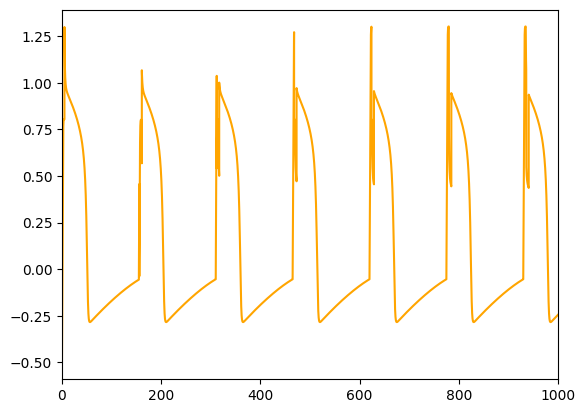

In [12]:
# Plot result - time domain - u vs. t
u_fhn = df_states_fhn['u'].tolist()
print(u_fhn[0:10])
print(t_fhn[0:10])

plt.plot(t_fhn,u_fhn)
plt.xlim(0,1000)
plt.show()
plt.plot(t_fhn,u_fhn - logical_non_aut(t_fhn, period=156), color='orange')  # Subtract the non-autonomous term to try to ID the original FHN dynamics
plt.xlim(0,1000)

Text(0.5, 1.0, 'FFT of FHN u Values')

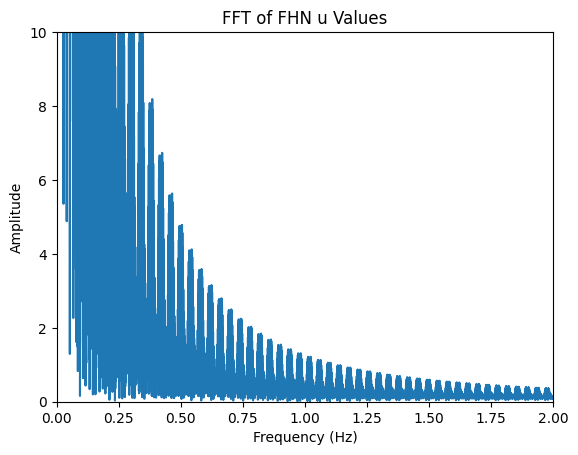

In [13]:
# Test analyzing time series in frequency space to see if we can tease out the non-autonomous signal.
# TODO Figure out what whether scipy.fft is being used incorrectly
w_fhn = fft.fft(u_fhn)
w_fhn = np.abs(w_fhn[0:len(w_fhn)//2]) # Take the first half of the FFT result, making sure to make all values real.
w = np.arange(0, 10, dt / 100.)
plt.plot(w, w_fhn)
plt.ylim(0, 10)
plt.xlim(0, 2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT of FHN u Values')